# Territorial Digital Divide: Geospatial Raster Analysis
## Cusco Region, Peru

In [1]:
# STEP 0: Environment Setup
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter
from scipy import stats
import seaborn as sns
import pandas as pd
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.transform import from_bounds
import scipy
import warnings
warnings.filterwarnings('ignore')

print("rasterio:", rasterio.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("scipy:", scipy.__version__)
print("seaborn:", sns.__version__)
print("pandas:", pd.__version__)

rasterio: 1.5.0
numpy: 2.4.4
matplotlib: 3.10.9
scipy: 1.17.1
seaborn: 0.13.2
pandas: 3.0.2


In [2]:
# STEP 1: Raster Loading and Inspection
def inspect_raster(path, name):
    with rasterio.open(path) as src:
        print(f"\n{'='*50}")
        print(f"  {name}")
        print(f"{'='*50}")
        print(f"  CRS:        {src.crs}")
        print(f"  Shape:      {src.height} x {src.width}")
        print(f"  Bands:      {src.count}")
        print(f"  NoData:     {src.nodata}")
        print(f"  Dtype:      {src.dtypes[0]}")
        print(f"  Bounds:     {src.bounds}")
        res = src.res
        print(f"  Resolution: {res[0]:.6f} deg x {res[1]:.6f} deg")
        print(f"  Approx km:  {res[0]*111:.3f} km x {res[1]*111:.3f} km")
        data = src.read(1)
        nodata = src.nodata
        profile = dict(src.profile)
        if nodata is not None:
            valid = data[data != nodata]
        else:
            valid = data[np.isfinite(data)]
        print(f"  Valid px:   {len(valid):,}")
        print(f"  Value range: [{valid.min():.4f}, {valid.max():.4f}]")
    return data, profile

vnl_data, vnl_profile = inspect_raster("../data/VNL_cusco_2025.tif", "VNL Nighttime Lights")
conn_data, conn_profile = inspect_raster("../data/kernel_cobmovil2019_50m.tif", "Mobile Coverage Kernel")


  VNL Nighttime Lights
  CRS:        EPSG:4326
  Shape:      1081 x 961
  Bands:      1
  NoData:     None
  Dtype:      float32
  Bounds:     BoundingBox(left=-74.00208248534999, bottom=-15.50208405735, right=-69.99791578664998, top=-10.99791735465)
  Resolution: 0.004167 deg x 0.004167 deg
  Approx km:  0.463 km x 0.463 km
  Valid px:   1,038,841
  Value range: [-1.5000, 1254.6145]

  Mobile Coverage Kernel
  CRS:        EPSG:32719
  Shape:      6116 x 7754
  Bands:      1
  NoData:     -3.4028234663852886e+38
  Dtype:      float32
  Bounds:     BoundingBox(left=-43080.11101302641, bottom=8337100.058809407, right=344619.88898697356, top=8642900.058809407)
  Resolution: 50.000000 deg x 50.000000 deg
  Approx km:  5550.000 km x 5550.000 km
  Valid px:   47,423,464
  Value range: [0.0000, 0.0000]


In [3]:
# STEP 2: Reprojection and Grid Alignment
with rasterio.open("../data/VNL_cusco_2025.tif") as vnl_src:
    vnl_transform = vnl_src.transform
    vnl_crs = vnl_src.crs
    vnl_shape = (vnl_src.height, vnl_src.width)
    vnl_arr = vnl_src.read(1).astype(np.float32)
    vnl_nodata = vnl_src.nodata

with rasterio.open("../data/kernel_cobmovil2019_50m.tif") as conn_src:
    conn_arr_orig = conn_src.read(1).astype(np.float32)
    conn_nodata = conn_src.nodata
    conn_aligned = np.empty(vnl_shape, dtype=np.float32)
    reproject(
        source=conn_arr_orig,
        destination=conn_aligned,
        src_transform=conn_src.transform,
        src_crs=conn_src.crs,
        dst_transform=vnl_transform,
        dst_crs=vnl_crs,
        resampling=Resampling.bilinear
    )

print(f"VNL shape:  {vnl_arr.shape}")
print(f"Conn shape: {conn_aligned.shape}")
assert vnl_arr.shape == conn_aligned.shape, "Shape mismatch!"
print("\u2713 Both arrays share identical dimensions")

VNL shape:  (1081, 961)
Conn shape: (1081, 961)
✓ Both arrays share identical dimensions


In [4]:
# STEP 3: Robust Normalization
def robust_normalize(arr, nodata_val=None, p_low=2, p_high=98):
    a = arr.copy().astype(np.float32)
    if nodata_val is not None:
        a[a == nodata_val] = 0
    a[~np.isfinite(a)] = 0
    a[a < 0] = 0
    lo, hi = np.percentile(a[a > 0], [p_low, p_high]) if np.any(a > 0) else (0, 1)
    norm = np.clip((a - lo) / (hi - lo + 1e-10), 0, 1)
    return norm

vnl_norm = robust_normalize(vnl_arr, vnl_nodata)
conn_norm = robust_normalize(conn_aligned, 0)

for name, arr in [("VNL norm", vnl_norm), ("Conn norm", conn_norm)]:
    print(f"{name}: min={arr.min():.4f} max={arr.max():.4f} mean={arr.mean():.4f} std={arr.std():.4f}")

VNL norm: min=0.0000 max=1.0000 mean=0.0035 std=0.0414
Conn norm: min=0.0000 max=1.0000 mean=0.0142 std=0.0807


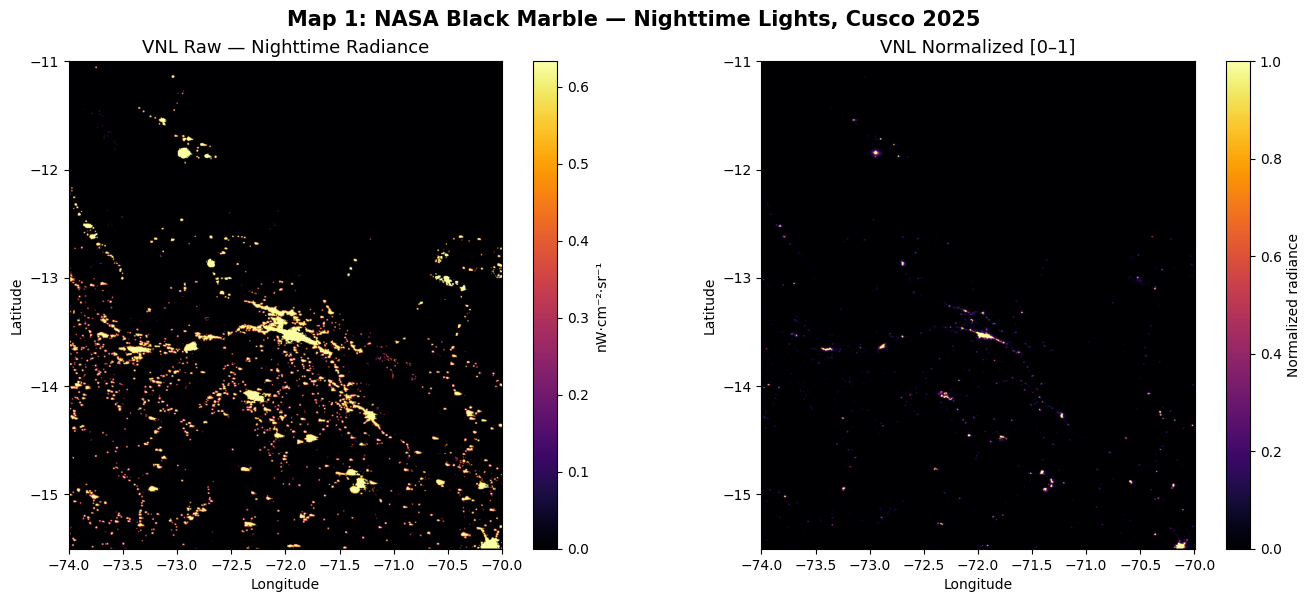

Observation: Bright zones correspond to urban centers (city of Cusco, Sicuani, Quillabamba).
Most of the region is dark, indicating sparse population or rural areas.


In [5]:
# STEP 4: Map 1 - VNL Nighttime Lights
with rasterio.open("../data/VNL_cusco_2025.tif") as src:
    extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(np.clip(vnl_arr, 0, np.percentile(vnl_arr, 98)), cmap='inferno', extent=extent)
axes[0].set_title("VNL Raw \u2014 Nighttime Radiance", fontsize=13)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="nW\u00b7cm\u207b\u00b2\u00b7sr\u207b\u00b9")

im1 = axes[1].imshow(vnl_norm, cmap='inferno', extent=extent, vmin=0, vmax=1)
axes[1].set_title("VNL Normalized [0\u20131]", fontsize=13)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="Normalized radiance")

plt.suptitle("Map 1: NASA Black Marble \u2014 Nighttime Lights, Cusco 2025", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../output/map1_vnl.png", dpi=150, bbox_inches='tight')
plt.show()
print("Observation: Bright zones correspond to urban centers (city of Cusco, Sicuani, Quillabamba).")
print("Most of the region is dark, indicating sparse population or rural areas.")

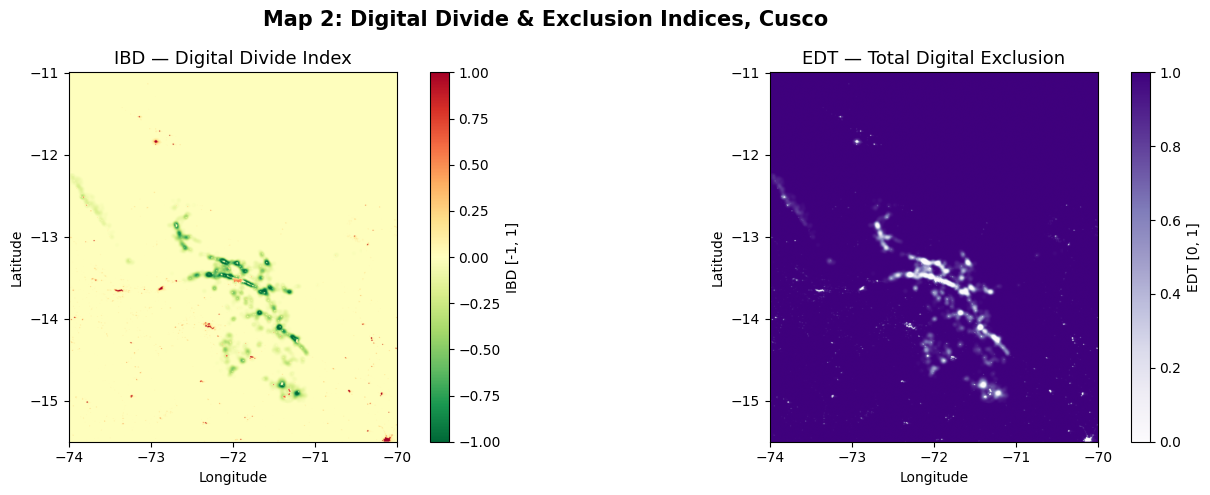

IBD: Red zones = high light but low connectivity (active digital divide).
EDT: Purple zones = neither light nor connectivity (maximum exclusion, deep rural areas).


In [6]:
# STEP 5: Map 2 - IBD and EDT
IBD = vnl_norm - conn_norm
EDT = (1 - vnl_norm) * (1 - conn_norm)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
im0 = axes[0].imshow(IBD, cmap='RdYlGn_r', extent=extent, vmin=-1, vmax=1)
axes[0].set_title("IBD \u2014 Digital Divide Index", fontsize=13)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="IBD [-1, 1]")

im1 = axes[1].imshow(EDT, cmap='Purples', extent=extent, vmin=0, vmax=1)
axes[1].set_title("EDT \u2014 Total Digital Exclusion", fontsize=13)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="EDT [0, 1]")

plt.suptitle("Map 2: Digital Divide & Exclusion Indices, Cusco", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../output/map2_ibd_edt.png", dpi=150, bbox_inches='tight')
plt.show()
print("IBD: Red zones = high light but low connectivity (active digital divide).")
print("EDT: Purple zones = neither light nor connectivity (maximum exclusion, deep rural areas).")

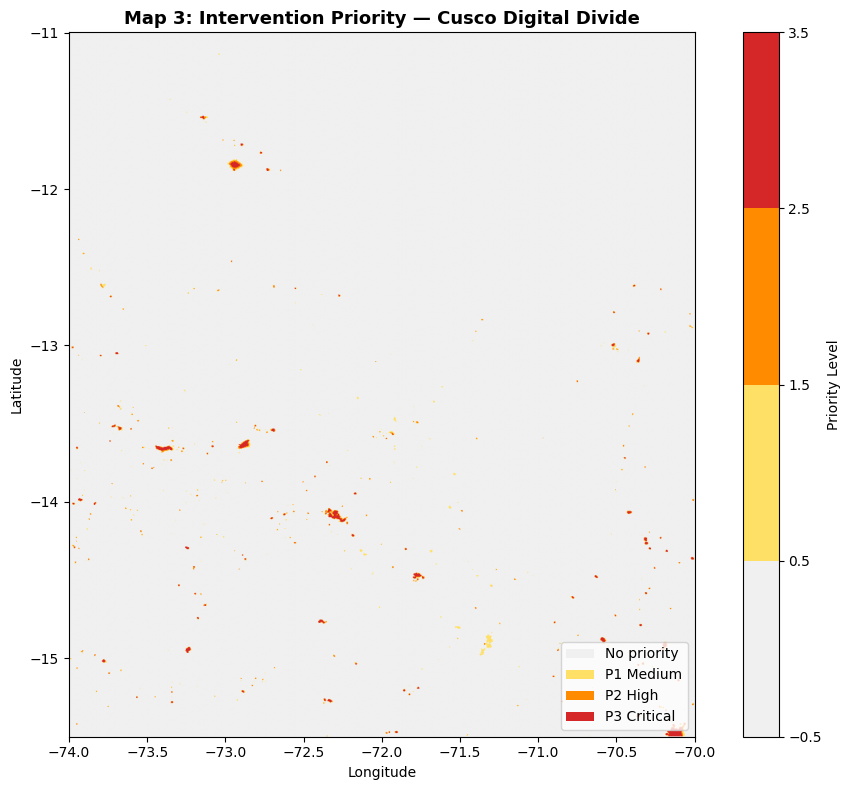

P1 Medium: 1,570 px (0.15%)
P2 High: 1,267 px (0.12%)
P3 Critical: 1,589 px (0.15%)


In [7]:
# STEP 6: Map 3 - Intervention Priority
priority = np.zeros_like(vnl_norm, dtype=np.uint8)
priority[(vnl_norm >= 0.10) & (conn_norm < 0.25)] = 1
priority[(vnl_norm >= 0.15) & (conn_norm < 0.15)] = 2
priority[(vnl_norm >= 0.30) & (conn_norm < 0.10)] = 3

cmap_p = mcolors.ListedColormap(['#f0f0f0','#ffe066','#ff8c00','#d62728'])
bounds_p = [-0.5, 0.5, 1.5, 2.5, 3.5]
norm_p = mcolors.BoundaryNorm(bounds_p, cmap_p.N)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(priority, cmap=cmap_p, norm=norm_p, extent=extent)
legend_els = [Patch(facecolor='#f0f0f0', label='No priority'),
              Patch(facecolor='#ffe066', label='P1 Medium'),
              Patch(facecolor='#ff8c00', label='P2 High'),
              Patch(facecolor='#d62728', label='P3 Critical')]
ax.legend(handles=legend_els, loc='lower right')
ax.set_title("Map 3: Intervention Priority \u2014 Cusco Digital Divide", fontsize=13, fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.colorbar(im, ax=ax, label="Priority Level")
plt.tight_layout()
plt.savefig("../output/map3_priority.png", dpi=150, bbox_inches='tight')
plt.show()

total_px = priority.size
for level, name in [(1,'P1 Medium'),(2,'P2 High'),(3,'P3 Critical')]:
    count = np.sum(priority == level)
    print(f"{name}: {count:,} px ({100*count/total_px:.2f}%)")

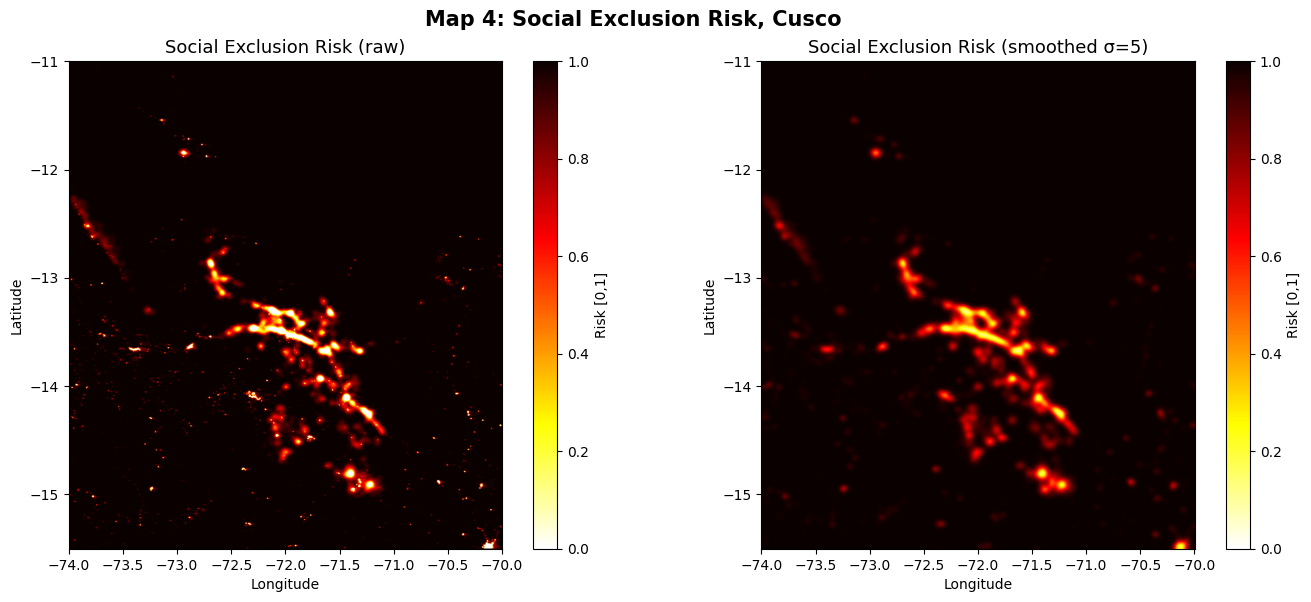

75th percentile risk: 1.0000
90th percentile risk: 1.0000


In [8]:
# STEP 7: Map 4 - Social Exclusion Risk
risk_raw = EDT * (1 - vnl_norm)
risk_norm = (risk_raw - risk_raw.min()) / (risk_raw.max() - risk_raw.min() + 1e-10)
risk_smooth = gaussian_filter(risk_norm, sigma=5)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im0 = axes[0].imshow(risk_norm, cmap='hot_r', extent=extent, vmin=0, vmax=1)
axes[0].set_title("Social Exclusion Risk (raw)", fontsize=13)
axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
plt.colorbar(im0, ax=axes[0], label="Risk [0,1]")

im1 = axes[1].imshow(risk_smooth, cmap='hot_r', extent=extent, vmin=0, vmax=1)
axes[1].set_title("Social Exclusion Risk (smoothed \u03c3=5)", fontsize=13)
axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
plt.colorbar(im1, ax=axes[1], label="Risk [0,1]")

plt.suptitle("Map 4: Social Exclusion Risk, Cusco", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("../output/map4_risk.png", dpi=150, bbox_inches='tight')
plt.show()
p75 = np.percentile(risk_norm, 75)
p90 = np.percentile(risk_norm, 90)
print(f"75th percentile risk: {p75:.4f}")
print(f"90th percentile risk: {p90:.4f}")

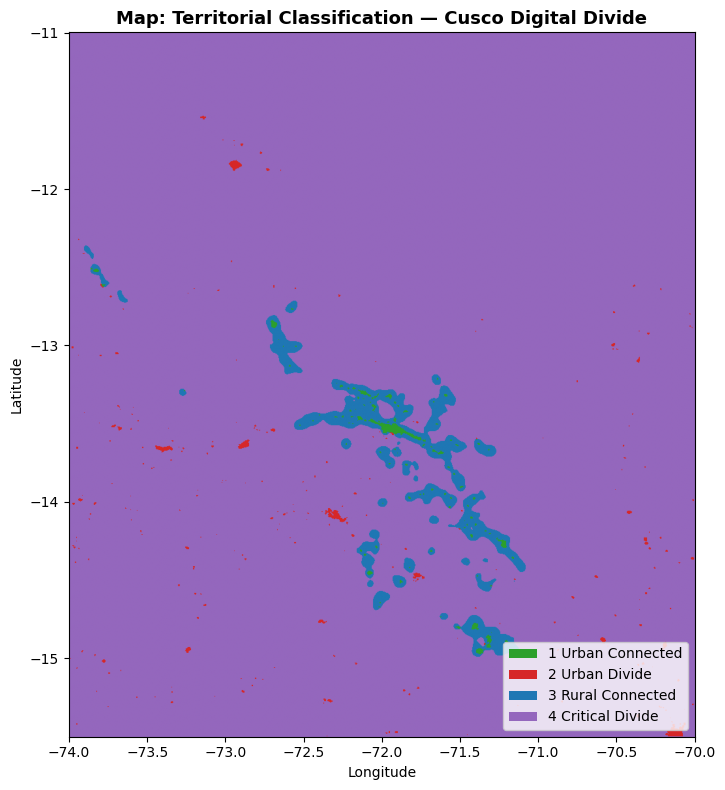

 Class            Name  Pixels   Pct  Area_km2
     1 Urban Connected    2098  0.20       1.9
     2    Urban Divide    2856  0.27       2.5
     3 Rural Connected   26543  2.56      23.7
     4 Critical Divide 1007344 96.97     898.1
✓ clasificacion_brecha.tif saved


In [9]:
# STEP 8: Territorial Classification
names = {1:'Urban Connected', 2:'Urban Divide', 3:'Rural Connected', 4:'Critical Divide'}

classif = np.zeros_like(vnl_norm, dtype=np.uint8)
classif[(vnl_norm >= 0.15) & (conn_norm >= 0.15)] = 1
classif[(vnl_norm >= 0.15) & (conn_norm < 0.15)]  = 2
classif[(vnl_norm < 0.15)  & (conn_norm >= 0.15)] = 3
classif[(vnl_norm < 0.15)  & (conn_norm < 0.15)]  = 4

class_colors = ['#2ca02c','#d62728','#1f77b4','#9467bd']
cmap_c = mcolors.ListedColormap(class_colors)
bounds_c = [0.5, 1.5, 2.5, 3.5, 4.5]
norm_c = mcolors.BoundaryNorm(bounds_c, cmap_c.N)

fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(classif, cmap=cmap_c, norm=norm_c, extent=extent)
legend_els = [Patch(facecolor='#2ca02c', label='1 Urban Connected'),
              Patch(facecolor='#d62728', label='2 Urban Divide'),
              Patch(facecolor='#1f77b4', label='3 Rural Connected'),
              Patch(facecolor='#9467bd', label='4 Critical Divide')]
ax.legend(handles=legend_els, loc='lower right')
ax.set_title("Map: Territorial Classification \u2014 Cusco Digital Divide", fontsize=13, fontweight='bold')
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.savefig("../output/map_classification.png", dpi=150, bbox_inches='tight')
plt.show()

pixel_size_km2 = (0.000269 * 111) ** 2
rows = []
total = classif.size
for cls, name in names.items():
    count = int(np.sum(classif == cls))
    rows.append({'Class': cls, 'Name': name, 'Pixels': count,
                 'Pct': round(100*count/total, 2), 'Area_km2': round(count*pixel_size_km2, 1)})
df_class = pd.DataFrame(rows)
print(df_class.to_string(index=False))

out_profile = {**vnl_profile, 'dtype':'uint8', 'count':1, 'nodata':0}
with rasterio.open("../output/clasificacion_brecha.tif", 'w', **out_profile) as dst:
    dst.write(classif, 1)
print("\u2713 clasificacion_brecha.tif saved")

=== Descriptive Stats by Class ===
  Class 1 Urban Connected | VNL: mean=0.518 std=0.326 min=0.150 max=1.000
  Class 1 Urban Connected | Conn: mean=0.655 std=0.307 min=0.150 max=1.000
  Class 1 Urban Connected | IBD: mean=-0.137 std=0.428 min=-0.850 max=0.843
  Class 2 Urban Divide | VNL: mean=0.481 std=0.313 min=0.150 max=1.000
  Class 2 Urban Divide | Conn: mean=0.006 std=0.023 min=0.000 max=0.149
  Class 2 Urban Divide | IBD: mean=0.475 std=0.315 min=0.007 max=1.000
  Class 3 Rural Connected | VNL: mean=0.015 std=0.027 min=0.000 max=0.150
  Class 3 Rural Connected | Conn: mean=0.394 std=0.239 min=0.150 max=1.000
  Class 3 Rural Connected | IBD: mean=-0.379 std=0.232 min=-1.000 max=-0.011
  Class 4 Critical Divide | VNL: mean=0.001 std=0.007 min=0.000 max=0.150
  Class 4 Critical Divide | Conn: mean=0.003 std=0.015 min=0.000 max=0.150
  Class 4 Critical Divide | IBD: mean=-0.002 std=0.016 min=-0.150 max=0.150

Pearson r=0.3129, p=0.0000e+00


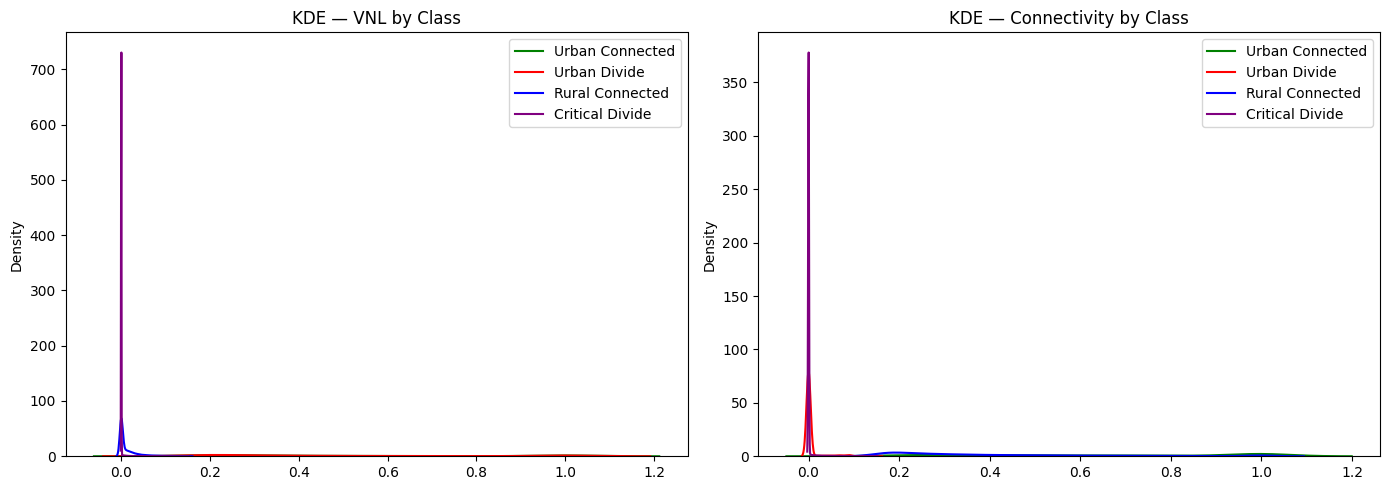


Welch t-test Class1 vs Class4:
  t=72.7308, p=0.0000e+00, Cohen's d=2.2457


In [10]:
# STEP 9: Statistical Summary
flat_vnl  = vnl_norm.flatten()
flat_conn = conn_norm.flatten()
flat_ibd  = IBD.flatten()
flat_cls  = classif.flatten()

print("=== Descriptive Stats by Class ===")
for cls, name in names.items():
    mask = flat_cls == cls
    for arr, label in [(flat_vnl,'VNL'),(flat_conn,'Conn'),(flat_ibd,'IBD')]:
        vals = arr[mask]
        print(f"  Class {cls} {name} | {label}: mean={vals.mean():.3f} std={vals.std():.3f} min={vals.min():.3f} max={vals.max():.3f}")

vnl_sub  = flat_vnl[::40]
conn_sub = flat_conn[::40]
r, p = stats.pearsonr(vnl_sub, conn_sub)
print(f"\nPearson r={r:.4f}, p={p:.4e}")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
colors_kde = {1:'green', 2:'red', 3:'blue', 4:'purple'}
for cls, name in names.items():
    mask = flat_cls == cls
    sns.kdeplot(flat_vnl[mask], ax=ax[0], label=name, color=colors_kde[cls])
    sns.kdeplot(flat_conn[mask], ax=ax[1], label=name, color=colors_kde[cls])
ax[0].set_title("KDE \u2014 VNL by Class"); ax[0].legend()
ax[1].set_title("KDE \u2014 Connectivity by Class"); ax[1].legend()
plt.tight_layout()
plt.savefig("../output/kde_plots.png", dpi=150, bbox_inches='tight')
plt.show()

c1 = flat_vnl[flat_cls == 1]
c4 = flat_vnl[flat_cls == 4]
t, p_val = stats.ttest_ind(c1, c4, equal_var=False)
cohens_d = (c1.mean() - c4.mean()) / np.sqrt((c1.std()**2 + c4.std()**2) / 2)
print(f"\nWelch t-test Class1 vs Class4:")
print(f"  t={t:.4f}, p={p_val:.4e}, Cohen's d={cohens_d:.4f}")

✓ All normalized rasters saved


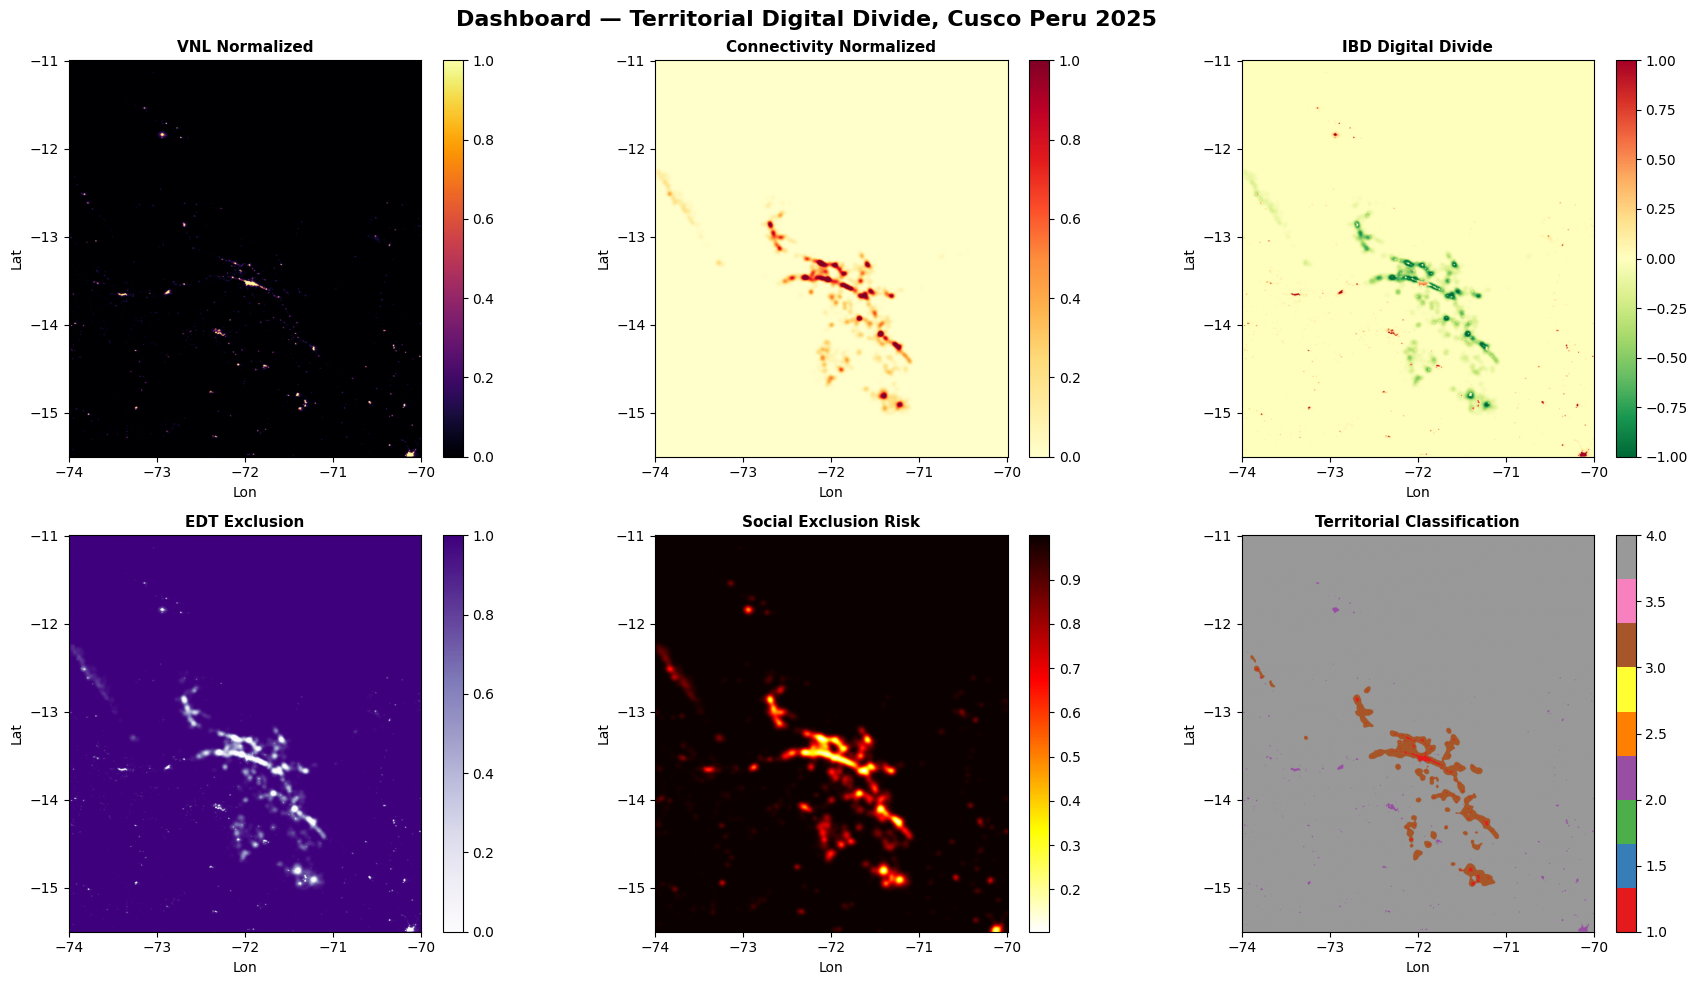

✓ Dashboard saved


In [11]:
# STEP 10: Export Deliverables
def save_norm_raster(arr, path):
    out_p = {**vnl_profile, 'dtype':'float32', 'count':1}
    with rasterio.open(path, 'w', **out_p) as dst:
        dst.write(arr.astype(np.float32), 1)

save_norm_raster(vnl_norm,  "../output/vnl_norm.tif")
save_norm_raster(conn_norm, "../output/conn_norm.tif")
save_norm_raster(IBD,       "../output/ibd_brecha_digital.tif")
print("\u2713 All normalized rasters saved")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
datasets = [
    (vnl_norm, 'inferno', 'VNL Normalized'),
    (conn_norm, 'YlOrRd', 'Connectivity Normalized'),
    (IBD, 'RdYlGn_r', 'IBD Digital Divide'),
    (EDT, 'Purples', 'EDT Exclusion'),
    (risk_smooth, 'hot_r', 'Social Exclusion Risk'),
    (classif.astype(float), 'Set1', 'Territorial Classification'),
]
for ax, (data, cmap, title) in zip(axes, datasets):
    im = ax.imshow(data, cmap=cmap, extent=extent)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.suptitle("Dashboard \u2014 Territorial Digital Divide, Cusco Peru 2025", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig("../output/dashboard_brecha_digital.png", dpi=150, bbox_inches='tight')
plt.show()
print("\u2713 Dashboard saved")